# Southern Women Network Analysis
## Bipartite Network: Women and Social Events (Davis, 1941)

This notebook analyzes the classic Southern Women dataset from a 1941 sociological study by Davis, Gardner, and Gardner. The dataset records the attendance of **18 women** at **14 social events** in the American South.

This is a **bipartite network** — a 2-node-type graph where connections only exist between two distinct groups (women and events), never within the same group.

Our goal is to answer two questions:
1. What can we infer about the **relationships between the women**?
2. What can we infer about the **relationships between the social events**?

## 1. Import Libraries

We use:
- `networkx` to load and analyze the bipartite network
- `matplotlib` and `seaborn` for visualizations
- `pandas` and `numpy` for data manipulation

In [1]:
import networkx as nx
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load the Dataset

NetworkX includes the Southern Women dataset as a built-in graph. The network is bipartite — nodes are labeled as either women (`bipartite=0`) or events (`bipartite=1`), and edges represent attendance.

In [2]:
# Load the Davis Southern Women dataset
G = nx.davis_southern_women_graph()

# Separate the two node sets
women = [n for n, d in G.nodes(data=True) if d['bipartite'] == 0]
events = [n for n, d in G.nodes(data=True) if d['bipartite'] == 1]

print(f'Total nodes: {G.number_of_nodes()}')
print(f'Total edges (attendances): {G.number_of_edges()}')
print(f'\nWomen ({len(women)}): {women}')
print(f'\nEvents ({len(events)}): {events}')

Total nodes: 32
Total edges (attendances): 89

Women (18): ['Evelyn Jefferson', 'Laura Mandeville', 'Theresa Anderson', 'Brenda Rogers', 'Charlotte McDowd', 'Frances Anderson', 'Eleanor Nye', 'Pearl Oglethorpe', 'Ruth DeSand', 'Verne Sanderson', 'Myra Liddel', 'Katherina Rogers', 'Sylvia Avondale', 'Nora Fayette', 'Helen Lloyd', 'Dorothy Murchison', 'Olivia Carleton', 'Flora Price']

Events (14): ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14']


## 3. Explore the Network Structure

Before diving into analysis, we look at basic properties of the network — how many events each woman attended, and how many women attended each event. This gives us a first sense of who is most active and which events were most popular.

In [3]:
# Degree = number of events attended (for women) or number of women who attended (for events)
women_degree = {n: G.degree(n) for n in women}
events_degree = {n: G.degree(n) for n in events}

# Create summary DataFrames
women_df = pd.DataFrame(list(women_degree.items()), columns=['Woman', 'Events Attended'])
women_df = women_df.sort_values('Events Attended', ascending=False).reset_index(drop=True)

events_df = pd.DataFrame(list(events_degree.items()), columns=['Event', 'Women Attended'])
events_df = events_df.sort_values('Women Attended', ascending=False).reset_index(drop=True)

print('Women by number of events attended:')
print(women_df.to_string(index=False))
print()
print('Events by number of women attended:')
print(events_df.to_string(index=False))

Women by number of events attended:
            Woman  Events Attended
 Evelyn Jefferson                8
 Theresa Anderson                8
     Nora Fayette                8
 Laura Mandeville                7
    Brenda Rogers                7
  Sylvia Avondale                7
 Katherina Rogers                6
      Helen Lloyd                5
      Myra Liddel                4
  Verne Sanderson                4
      Ruth DeSand                4
      Eleanor Nye                4
 Frances Anderson                4
 Charlotte McDowd                4
 Pearl Oglethorpe                3
Dorothy Murchison                2
  Olivia Carleton                2
      Flora Price                2

Events by number of women attended:
Event  Women Attended
   E8              14
   E9              12
   E7              10
   E5               8
   E6               8
   E3               6
  E12               6
  E10               5
   E4               4
  E11               4
   E1               

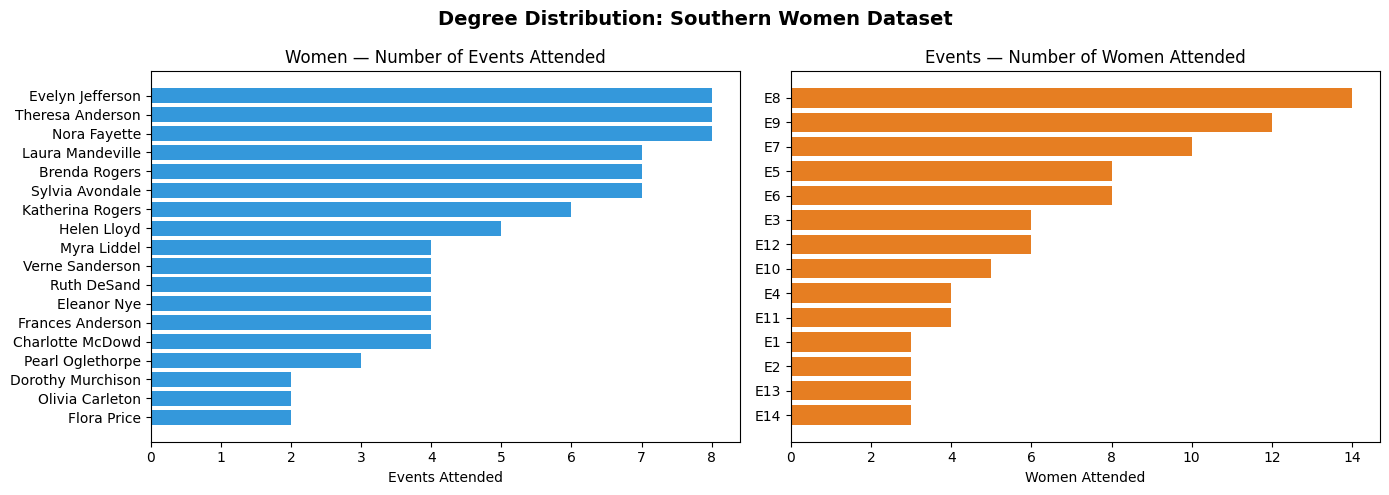

In [4]:
# Visualize degree distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Degree Distribution: Southern Women Dataset', fontsize=14, fontweight='bold')

axes[0].barh(women_df['Woman'], women_df['Events Attended'], color='#3498db')
axes[0].set_title('Women — Number of Events Attended')
axes[0].set_xlabel('Events Attended')
axes[0].invert_yaxis()

axes[1].barh(events_df['Event'], events_df['Women Attended'], color='#e67e22')
axes[1].set_title('Events — Number of Women Attended')
axes[1].set_xlabel('Women Attended')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Visualize the Bipartite Network

Here we visualize the full bipartite graph, with women on the left and events on the right. Each edge represents one woman attending one event. This gives an intuitive picture of the network structure and which women and events are most connected.

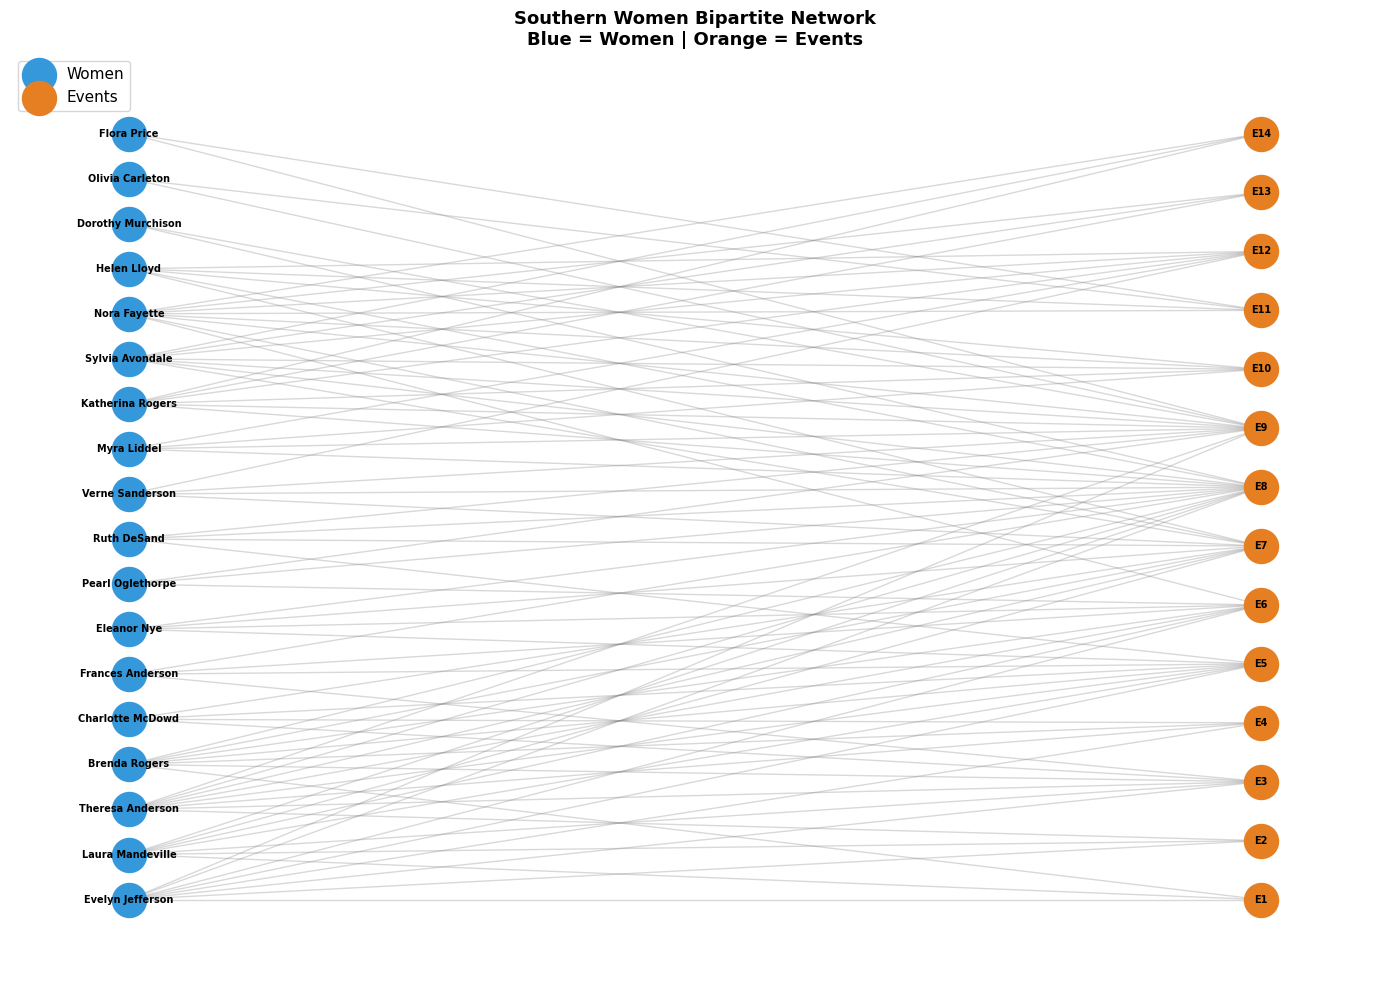

In [5]:
plt.figure(figsize=(14, 10))

# Create bipartite layout
pos = nx.bipartite_layout(G, women)

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=women, node_color='#3498db', node_size=600, label='Women')
nx.draw_networkx_nodes(G, pos, nodelist=events, node_color='#e67e22', node_size=600, label='Events')

# Draw edges and labels
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')

plt.title('Southern Women Bipartite Network\nBlue = Women | Orange = Events', fontsize=13, fontweight='bold')
plt.legend(scatterpoints=1, loc='upper left', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Relationships Between Women — Projected Network

To analyze relationships **among the women**, we create a **projection** of the bipartite graph onto the women nodes. In this projected graph:
- Each node is a woman
- Two women are connected if they attended **at least one event together**
- Edge weights represent **how many events they attended together** — a proxy for social closeness

Women who share many events together are likely to have stronger social ties.

In [6]:
# Create weighted projection onto women
women_projection = bipartite.weighted_projected_graph(G, women)

print(f'Women projection — Nodes: {women_projection.number_of_nodes()}, Edges: {women_projection.number_of_edges()}')
print()

# Show strongest connections (highest shared event counts)
edges = [(u, v, d['weight']) for u, v, d in women_projection.edges(data=True)]
edges_df = pd.DataFrame(edges, columns=['Woman 1', 'Woman 2', 'Shared Events'])
edges_df = edges_df.sort_values('Shared Events', ascending=False).reset_index(drop=True)

print('Top 10 strongest woman-to-woman connections (shared events):')
print(edges_df.head(10).to_string(index=False))

Women projection — Nodes: 18, Edges: 139

Top 10 strongest woman-to-woman connections (shared events):
         Woman 1          Woman 2  Shared Events
Evelyn Jefferson Theresa Anderson              7
Katherina Rogers  Sylvia Avondale              6
Laura Mandeville    Brenda Rogers              6
Evelyn Jefferson    Brenda Rogers              6
Laura Mandeville Theresa Anderson              6
Evelyn Jefferson Laura Mandeville              6
 Sylvia Avondale     Nora Fayette              6
Theresa Anderson    Brenda Rogers              6
Katherina Rogers     Nora Fayette              5
   Brenda Rogers Charlotte McDowd              4


In [7]:
# Compute degree centrality on women projection
degree_cent = nx.degree_centrality(women_projection)
eigen_cent = nx.eigenvector_centrality(women_projection, max_iter=1000)

centrality_df = pd.DataFrame({
    'Woman': list(degree_cent.keys()),
    'Degree Centrality': [round(v, 4) for v in degree_cent.values()],
    'Eigenvector Centrality': [round(v, 4) for v in eigen_cent.values()]
}).sort_values('Degree Centrality', ascending=False).reset_index(drop=True)

print('Centrality Measures — Women Projection:')
print(centrality_df.to_string(index=False))

Centrality Measures — Women Projection:
            Woman  Degree Centrality  Eigenvector Centrality
 Evelyn Jefferson             1.0000                  0.2535
      Ruth DeSand             1.0000                  0.2535
      Helen Lloyd             1.0000                  0.2535
     Nora Fayette             1.0000                  0.2535
  Sylvia Avondale             1.0000                  0.2535
  Verne Sanderson             1.0000                  0.2535
 Theresa Anderson             1.0000                  0.2535
 Pearl Oglethorpe             0.9412                  0.2432
      Myra Liddel             0.9412                  0.2432
 Katherina Rogers             0.9412                  0.2432
Dorothy Murchison             0.9412                  0.2432
      Eleanor Nye             0.8824                  0.2310
 Frances Anderson             0.8824                  0.2310
 Laura Mandeville             0.8824                  0.2310
    Brenda Rogers             0.8824         

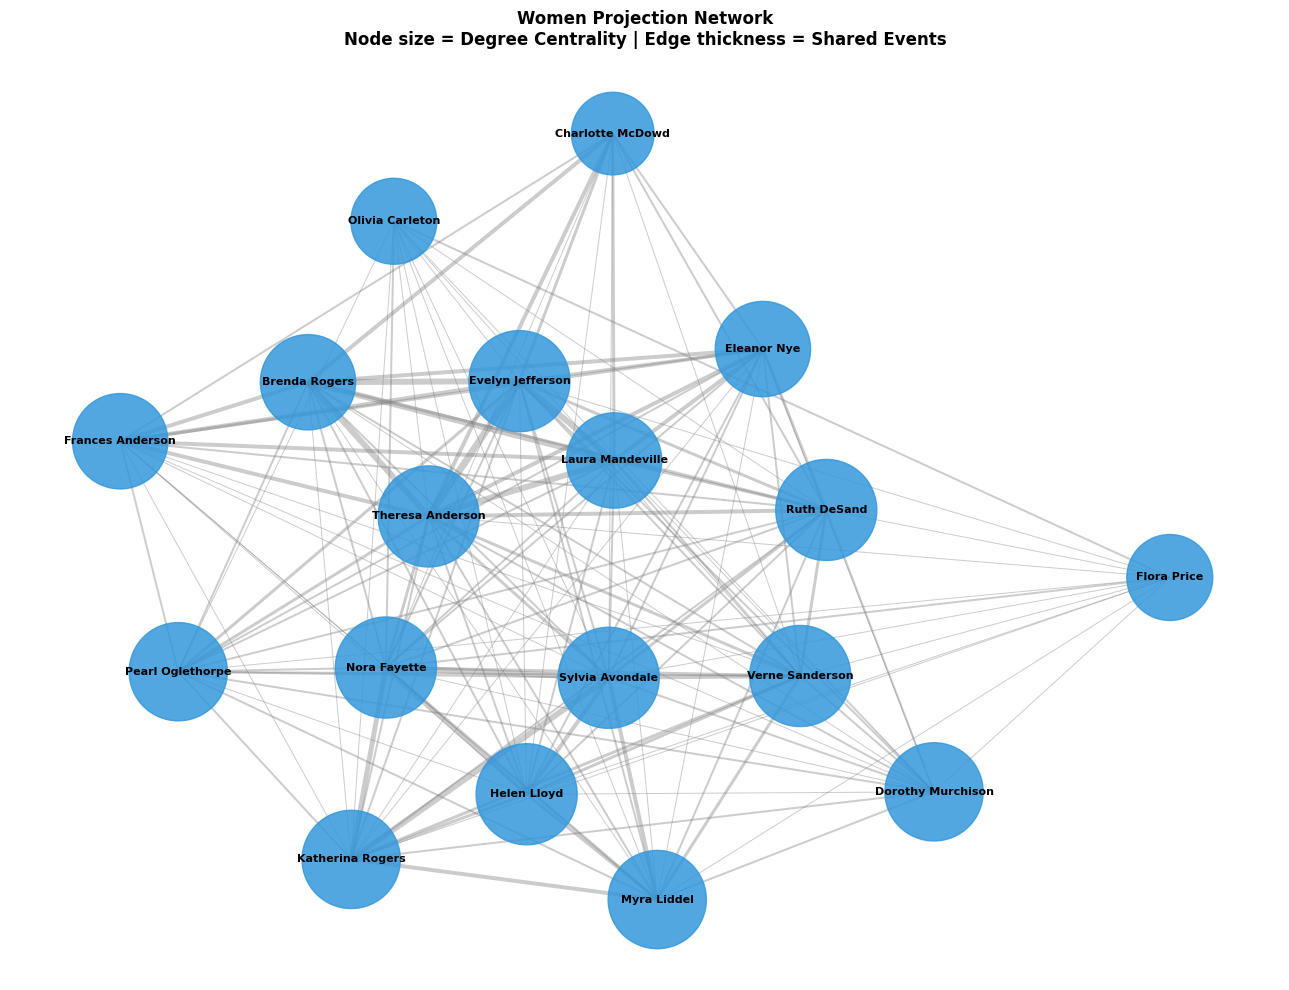

In [8]:
# Visualize women projection — node size = degree centrality, edge thickness = shared events
plt.figure(figsize=(13, 10))

pos = nx.spring_layout(women_projection, seed=42, k=1.2)

# Scale node sizes and edge widths
node_sizes = [degree_cent[n] * 5000 + 300 for n in women_projection.nodes()]
edge_weights = [d['weight'] for _, _, d in women_projection.edges(data=True)]
max_w = max(edge_weights)
edge_widths = [w / max_w * 5 for w in edge_weights]

nx.draw_networkx_nodes(women_projection, pos, node_color='#3498db', node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(women_projection, pos, width=edge_widths, alpha=0.4, edge_color='gray')
nx.draw_networkx_labels(women_projection, pos, font_size=8, font_weight='bold')

plt.title('Women Projection Network\nNode size = Degree Centrality | Edge thickness = Shared Events', 
          fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Relationships Between Events — Projected Network

We now project the bipartite graph onto the **events** side. In this projected network:
- Each node is a social event
- Two events are connected if they were **attended by at least one common woman**
- Edge weights represent **how many women attended both events**

Events with many shared attendees likely served similar social circles or occurred close together in time/context.

In [9]:
# Create weighted projection onto events
events_projection = bipartite.weighted_projected_graph(G, events)

print(f'Events projection — Nodes: {events_projection.number_of_nodes()}, Edges: {events_projection.number_of_edges()}')
print()

# Show strongest event-to-event connections
evt_edges = [(u, v, d['weight']) for u, v, d in events_projection.edges(data=True)]
evt_edges_df = pd.DataFrame(evt_edges, columns=['Event 1', 'Event 2', 'Shared Women'])
evt_edges_df = evt_edges_df.sort_values('Shared Women', ascending=False).reset_index(drop=True)

print('Top 10 strongest event-to-event connections (shared attendees):')
print(evt_edges_df.head(10).to_string(index=False))

Events projection — Nodes: 14, Edges: 66

Top 10 strongest event-to-event connections (shared attendees):
Event 1 Event 2  Shared Women
     E8      E9             9
     E7      E8             8
     E5      E8             7
     E6      E8             7
     E5      E6             6
     E5      E7             6
     E3      E5             6
     E3      E8             5
     E6      E7             5
     E8     E12             5


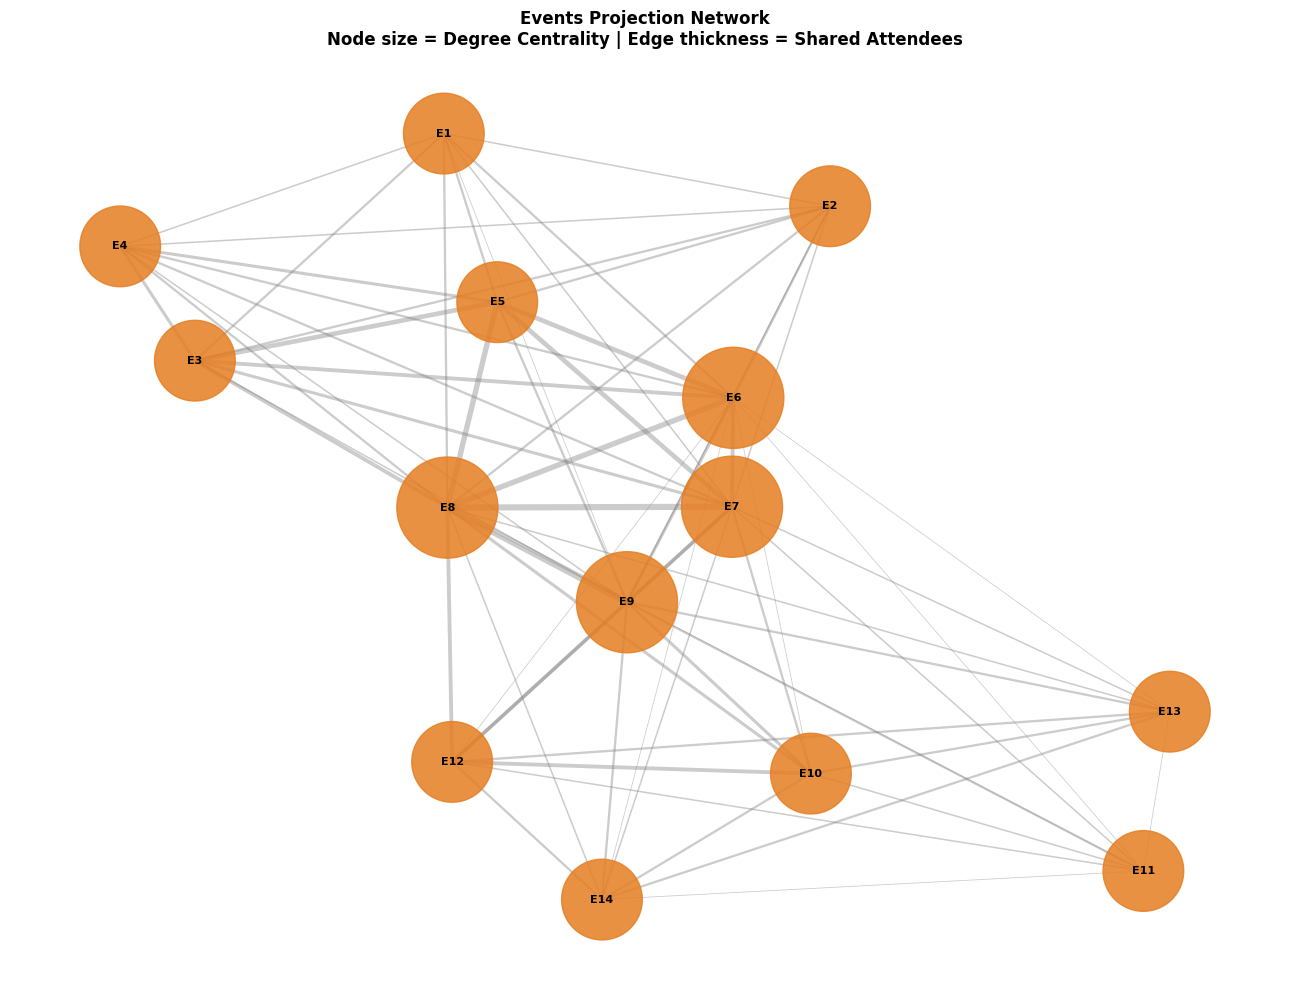

In [10]:
# Visualize events projection
plt.figure(figsize=(13, 10))

evt_degree_cent = nx.degree_centrality(events_projection)
pos = nx.spring_layout(events_projection, seed=42, k=1.2)

node_sizes = [evt_degree_cent[n] * 5000 + 300 for n in events_projection.nodes()]
edge_weights = [d['weight'] for _, _, d in events_projection.edges(data=True)]
max_w = max(edge_weights)
edge_widths = [w / max_w * 5 for w in edge_weights]

nx.draw_networkx_nodes(events_projection, pos, node_color='#e67e22', node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(events_projection, pos, width=edge_widths, alpha=0.4, edge_color='gray')
nx.draw_networkx_labels(events_projection, pos, font_size=8, font_weight='bold')

plt.title('Events Projection Network\nNode size = Degree Centrality | Edge thickness = Shared Attendees',
          fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 7. Co-Attendance Heatmap

A heatmap of the co-attendance matrix shows at a glance how many events each pair of women attended together. Darker cells indicate stronger social connections. This is another way to identify clusters of women who moved in the same social circles.

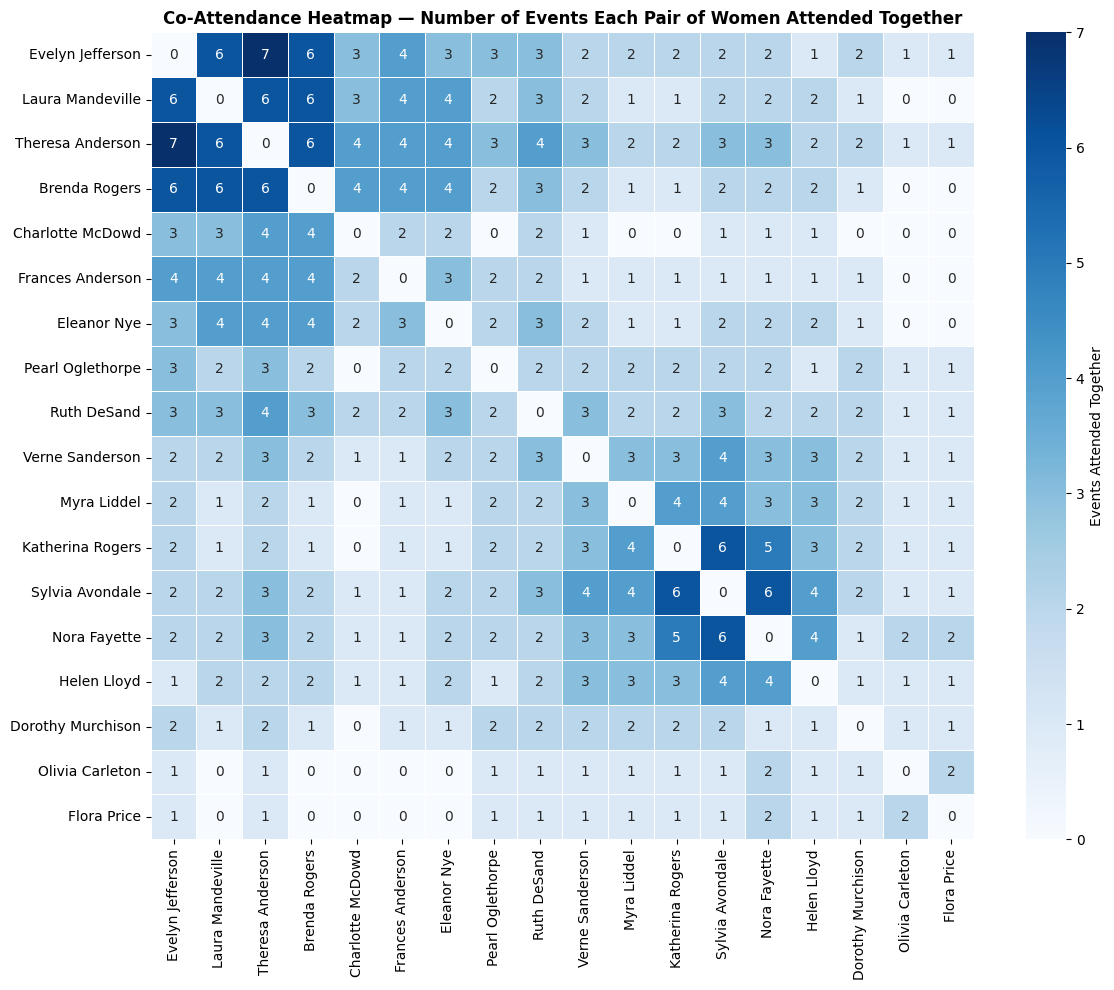

In [11]:
# Build co-attendance matrix
coattendance = bipartite.biadjacency_matrix(G, row_order=women, column_order=events).toarray()
co_matrix = coattendance @ coattendance.T
np.fill_diagonal(co_matrix, 0)  # zero out diagonal (self-attendance)

co_df = pd.DataFrame(co_matrix, index=women, columns=women)

plt.figure(figsize=(12, 10))
sns.heatmap(co_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Events Attended Together'})
plt.title('Co-Attendance Heatmap — Number of Events Each Pair of Women Attended Together',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Community Detection

We apply a community detection algorithm to the women's projection network to identify natural clusters — groups of women who socialized primarily with each other. This reveals subgroups within the broader social circle.

In [12]:
# Detect communities using greedy modularity
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(women_projection))

print(f'Number of communities detected: {len(communities)}')
print()
for i, community in enumerate(communities):
    print(f'Community {i+1}: {sorted(community)}')

Number of communities detected: 2

Community 1: ['Dorothy Murchison', 'Evelyn Jefferson', 'Flora Price', 'Helen Lloyd', 'Katherina Rogers', 'Myra Liddel', 'Nora Fayette', 'Olivia Carleton', 'Pearl Oglethorpe', 'Ruth DeSand', 'Sylvia Avondale', 'Theresa Anderson']
Community 2: ['Brenda Rogers', 'Charlotte McDowd', 'Eleanor Nye', 'Frances Anderson', 'Laura Mandeville', 'Verne Sanderson']


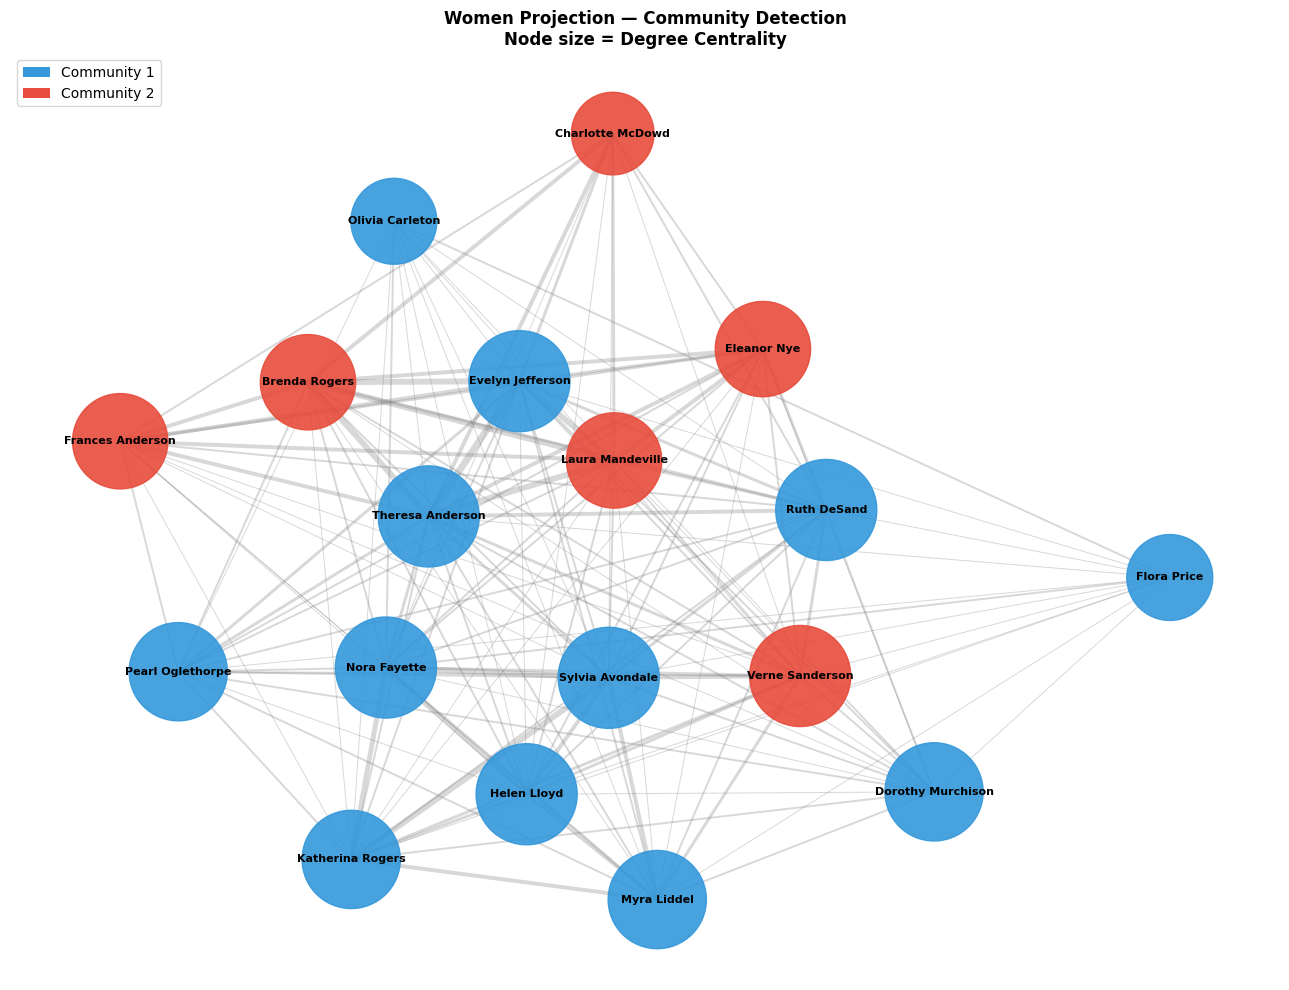

In [13]:
# Visualize communities with different colors
plt.figure(figsize=(13, 10))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
node_colors = {}
for i, community in enumerate(communities):
    for woman in community:
        node_colors[woman] = colors[i % len(colors)]

color_list = [node_colors[n] for n in women_projection.nodes()]
node_sizes = [degree_cent[n] * 5000 + 300 for n in women_projection.nodes()]
edge_weights = [d['weight'] for _, _, d in women_projection.edges(data=True)]
edge_widths = [w / max(edge_weights) * 5 for w in edge_weights]

pos = nx.spring_layout(women_projection, seed=42, k=1.2)
nx.draw_networkx_nodes(women_projection, pos, node_color=color_list, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(women_projection, pos, width=edge_widths, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(women_projection, pos, font_size=8, font_weight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=f'Community {i+1}') for i in range(len(communities))]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.title('Women Projection — Community Detection\nNode size = Degree Centrality', fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 9. Conclusions

### Relationships Between the Women

The projection of the bipartite graph onto the women nodes reveals a remarkably dense social network. The centrality results show that 7 women — Evelyn Jefferson, Ruth DeSand, Helen Lloyd, Nora Fayette, Sylvia Avondale, Verne Sanderson, and Theresa Anderson — have a degree centrality of **1.0**, meaning they are connected to every other woman in the network. These women attended enough events to overlap with all other members of the group.

The most peripheral women are **Charlotte McDowd** (degree centrality: 0.647), followed by **Olivia Carleton** and **Flora Price** (both 0.706). These women attended only 2–4 events each and had more limited social reach within the group.

The strongest individual connections were between **Evelyn Jefferson and Theresa Anderson** (7 shared events), followed by several pairs — including Laura Mandeville/Brenda Rogers, Theresa Anderson/Brenda Rogers, and Sylvia Avondale/Nora Fayette — who each shared 6 events. These pairs likely formed the tightest social bonds in the group.

Community detection identified exactly **2 communities**:
- **Community 1** (12 women): Evelyn Jefferson, Theresa Anderson, Nora Fayette, Sylvia Avondale, Katherina Rogers, Helen Lloyd, Ruth DeSand, Myra Liddel, Pearl Oglethorpe, Dorothy Murchison, Olivia Carleton, and Flora Price
- **Community 2** (6 women): Laura Mandeville, Brenda Rogers, Eleanor Nye, Frances Anderson, Verne Sanderson, and Charlotte McDowd

This split mirrors the classic finding from the original 1941 study — a larger core group centered around Evelyn Jefferson and Theresa Anderson, and a smaller peripheral group centered around Laura Mandeville and Brenda Rogers.

### Relationships Between the Events

The events projection shows a clear hierarchy of social importance. **E8** was by far the most central event — attended by all 14 women and sharing the strongest connections with E9 (9 shared attendees) and E7 (8 shared attendees). E8, E9, and E7 form the core of the events network, representing the major social gatherings that brought the broadest cross-section of women together.

At the other end, events **E1, E2, E13, and E14** were the most peripheral — each attended by only 3 women — and represent smaller, more exclusive gatherings with limited overlap with the broader group.

### Broader Takeaway

Despite being over 80 years old, this dataset remains a useful benchmark for network analysis precisely because its bipartite structure is clean and interpretable. The patterns of co-attendance reveal real social structure — who was central, who was peripheral, and how subgroups formed — using only attendance records and no direct self-reported social ties.